# CNN - Оценка на модела (Evaluation)
Този ноутбук зарежда обучения модел и го оценява върху тестовия набор от данни.

In [1]:
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.models.CNN_model import AudioCNN
from src.data_processing.audio_dataset import AudioFolderDataset

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Използвано устройство: {DEVICE}")

TEST_CSV = "../data/test_split.csv"
AUDIO_DIR = "../data/Dataset_Final"
MODEL_WEIGHTS = "../models/best_cnn.pth"
BATCH_SIZE = 32

Използвано устройство: cpu


In [3]:
print("Зареждане на тестовите данни...")
# Използвай новия параметър csv_file
test_dataset = AudioFolderDataset(root_dir="../data/Dataset_Final", csv_file=TEST_CSV, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Брой тестови записи: {len(test_dataset)}")


Зареждане на тестовите данни...
Зареждане на данни от сплит файл: ../data/test_split.csv
Брой тестови записи: 443


In [4]:
print("Инициализация на модела...")
model = AudioCNN(n_classes=8).to(DEVICE)

print("Зареждане на запазените тегла...")
if os.path.exists(MODEL_WEIGHTS):
    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=DEVICE))
    model.eval()
    print("Моделът е зареден успешно!")
else:
    print(f"ГРЕШКА: Файлът с теглата не е намерен на път {MODEL_WEIGHTS}")

Инициализация на модела...
Зареждане на запазените тегла...
Моделът е зареден успешно!


In [5]:
all_preds = []
all_labels = []

print("Стартиране на инференцията...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Оценката приключи!")

test_acc = accuracy_score(all_labels, all_preds)
print(f"Тестова точност (Test Accuracy): {test_acc:.4f} ({test_acc*100:.2f}%)")

Стартиране на инференцията...


Testing:   0%|          | 0/14 [00:00<?, ?it/s]

Оценката приключи!
Тестова точност (Test Accuracy): 0.7359 (73.59%)


In [6]:
class_names = [
    "Baby_Cry", "Background", "Car_Horn", "Construction", 
    "Dog_Bark", "Door_Signal", "Glass_Break", "Siren_Alarm"
]


print("--- Доклад от класификацията (Classification Report) ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

--- Доклад от класификацията (Classification Report) ---
              precision    recall  f1-score   support

    Baby_Cry       0.94      0.38      0.54        40
  Background       0.79      0.89      0.84        70
    Car_Horn       0.91      0.91      0.91        43
Construction       0.78      0.87      0.82        70
    Dog_Bark       0.46      0.87      0.60        70
 Door_Signal       0.88      0.53      0.66        40
 Glass_Break       0.00      0.00      0.00        40
 Siren_Alarm       0.96      0.96      0.96        70

    accuracy                           0.74       443
   macro avg       0.71      0.67      0.66       443
weighted avg       0.72      0.74      0.70       443



/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with 

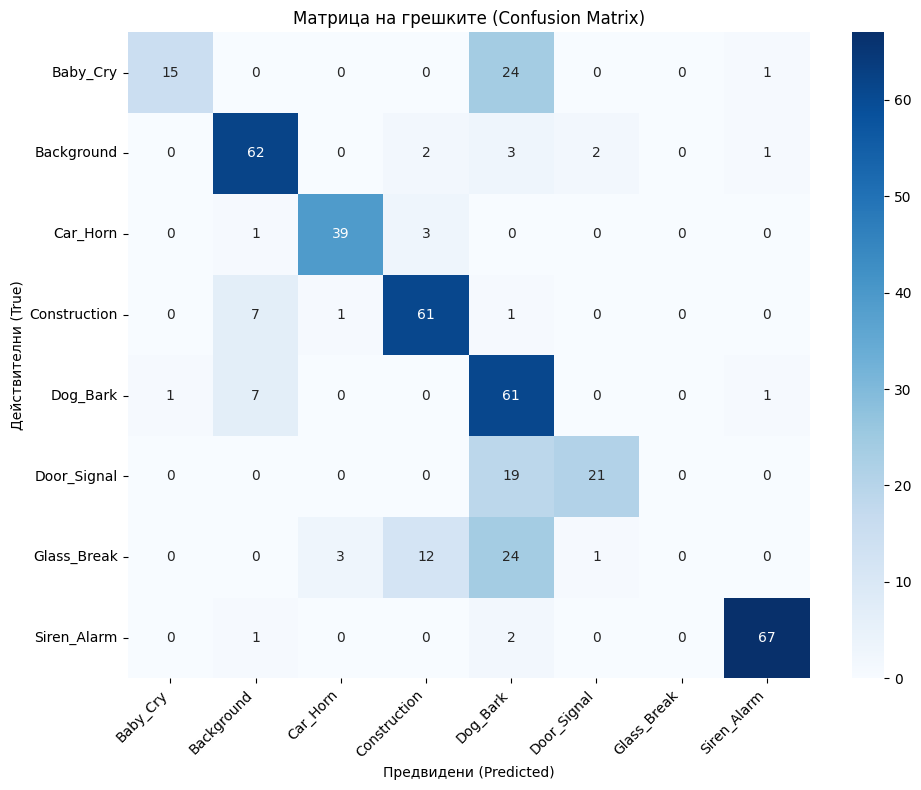

In [7]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предвидени (Predicted)')
plt.ylabel('Действителни (True)')
plt.title('Матрица на грешките (Confusion Matrix)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Анализ на резултатите: AudioCNN Sound Classification
1. Общ преглед на производителността
Моделът постига обща точност (Accuracy) от 74% върху тестовия набор от данни. Въпреки че е по-лек и бърз, AudioCNN среща сериозни затруднения при разграничаването на сложни акустични модели в сравнение с MobileNetV2.

Ключови метрики:

Precision (Macro Avg): 0.71

Recall (Macro Avg): 0.67

F1-Score (Weighted Avg): 0.70

2. Детайлен анализ по класове
✅ Силни страни (Висока надеждност)

🚨 Siren_Alarm: Това е най-стабилният клас с 0.96 Recall и 0.96 Precision. Чистата структура на сирените позволява дори на по-простия CNN да ги идентифицира почти безпогрешно (67 от 70 записа са уловени).

🚗 Car_Horn: Много добър резултат с 0.91 F1-score. Клаксоните са разпознати правилно в 39 от 43 случая.

🛠️ Construction & 🤫 Background: Тези класове се представят солидно с Recall съответно 0.87 и 0.89. Моделът успява да филтрира фоновия шум достатъчно добре, за да не генерира твърде много фалшиви сигнали.

⚠️ Проблемни зони (Висок риск от грешки)

🐕 Dog_Bark (Precision 0.46): Изключително ниска прецизност. Повече от половината пъти, когато моделът „чува“ куче, това всъщност е друг звук (често бебе или чукане по врата).

👶 Baby_Cry (Recall 0.38): Моделът пропуска над 60% от записите на бебешки плач. Основната част от грешките (24 случая) отиват към класа Dog_Bark.

🔔 Door_Signal (Recall 0.53): Почти половината от случаите на звънец или чукане са пропуснати, отново класифицирани погрешно като кучешки лай.

3. Критичен отказ: Glass_Break
Glass_Break (0.00 Precision / 0.00 Recall): Моделът напълно се проваля тук. Нито един запис на чупещо се стъкло не е разпознат правилно.

Къде отиват грешките? 24 записа са класифицирани като Dog_Bark, а 12 като Construction. Това показва, че AudioCNN не е достатъчно „дълбок“, за да улови специфичните микро-детайли в честотния спектър на чупещото се стъкло.